<!--
This notebook presents the usage of the `ve_run` command to run the example data.
We want the notebook to be dynamic - so that updates to the model get included
automatically but we don't want to expose a new user to a load of tricky code from
running the model within the notebook.

So - the notebook uses `code-block` entries to show the code and then contains
`code-cell` blocks with 'remove-cell' tags to run the actual model building in the
background. This cells will only execute successfully on systems with a bash shell.
-->

# Using the Virtual Ecosystem

This page provides a brief demonstration of the Virtual Ecosystem model in operation.
Once you have [installed the Virtual Ecosystem](./installing_ve.md), you should be able
to replicate this example on your own computer using the commands below.

## Example model data

The demonstration requires an [installation of the example data](./example_data.md)
provided with the Virtual Ecosystem package. If you have previously attempted to run
this example then the simulation will refuse to overwrite existing output files. You can
either:

* delete the existing example data folder and reinstall it,
* create a fresh installation using a different location, or
* create and use a new output directory with the existing example data folder.

It is worth re-reading the [example data page](./example_data.md) to get an overview of
the directory structure and the configuration and data files.

In [1]:
%%bash
# Remove any existing VE data directory in the execution directory
if [ -d ve_example ]; then
  rm -r ve_example
fi

export PYTHONUNBUFFERED=1
ve_run --install-example .

Example directory created at:
ve_example


## The `ve_run` command

You've already used this command to install the example data but most of the options to
the `ve_run` command are used to run the simulation. The `--help` option can be used to
show the various arguments that can be used to set how a model runs:

`````{tab-set}
:sync-group: operating_system

````{tab-item} macOS/Linux
:sync: macoslinux

```{code-block} shell
ve_run --help
```
````

````{tab-item} Windows (CMD)
:sync: windows-cmd

```{code-block} shell
ve_run --help
```
````

````{tab-item} Windows (Powershell)
:sync: windows-powershell

```{code-block} powershell
ve_run --help
```
````


`````

In [2]:
%%bash
# Code to actually get the command line help
export PYTHONUNBUFFERED=1
ve_run --help

usage: ve_run [-h] [--version] [--install-example INSTALL_EXAMPLE] [-o OUTPATH] [-c CLI_CONFIG] [--validate-config-only] [-p CLI_PATHS] [--logfile LOGFILE] [-q] [-n] [cfg_paths ...]

Configure and run a Virtual Ecosystem simulation.

This program sets up and runs a Virtual Ecosystem simulation. The program expects
to be provided with paths to TOML formatted configuration files for the simulation.
The configuration is modular: a directory path can be used to add all TOML
configuration files in the directory, or individual file paths can be used to select
specific combinations of configuration files. These are combined and validated and
then used to initialise and run the model.

As an alternative to providing configuration paths, the `--install-example` option
allows users to provide a location where a simple example set of datasets and
configuration files provided with the Virtual Ecosystem package can be installed.
This option will create a `ve_example` directory in the location, and 

## Running the example model

The code below runs a simulation using the example data. The command uses the command
line options to set the following arguments:

1. It points to the files in `config` directory that should be used configure the model.
   If a directory contains _only_ the set of configuration files you want to use, you
   can just provide the directory path, but if the directory contains alternative
   configuration options then you need to give the specific file paths.

1. It sets the output directory to be used by the simulation to `out`. You could create
   a new output directory (e.g. `out_test_2`) and change this to run a new simulation
   using the existing data.

1. It redirects the model logging to a file in the output directory, rather than
   printing it all to screen.

1. It sets the `--to-netcdf` option to compile the Zarr output directory into a single
   NetCDF file. This is explained in the [results section](#looking-at-the-results)
   below.

When the detailed logging is redirected to a file, the command generates a short
progress report to show the model running. This can be made shorter or completely muted
by using the `-q` argument: repeat the argument to remove more details (e.g. `-qq` or
`-qqq`).

```{warning}
If the path provided for the log points to a file that already exists the detailed
logging is added to the end of the file rather than creating a new file. We would
recommend creating a new logfile for each simulation as reusing files in this way can
create confusion.
```

In the example code below, the ve_example folder has been previously installed under the
directory /tmp/

`````{tab-set}
:sync-group: operating_system

````{tab-item} macOS/Linux
:sync: macoslinux

```{code-block} shell
ve_run /tmp/ve_example/config/data_config.toml \
    /tmp/ve_example/config/abiotic_simple_config.toml \
    /tmp/ve_example/config/animal_config.toml \
    /tmp/ve_example/config/hydrology_config.toml \
    /tmp/ve_example/config/litter_config.toml \
    /tmp/ve_example/config/plant_config.toml \
    /tmp/ve_example/config/soil_config.toml \
    --out /tmp/ve_example/out \
    --logfile /tmp/ve_example/out/logfile.log \
    --to-netcdf

```
````

````{tab-item} Windows (CMD)
:sync: windows-cmd

```{code-block} shell
ve_run C:\tmp\ve_example\config\data_config.toml ^
    C:\tmp\ve_example\config\abiotic_simple_config.toml ^
    C:\tmp\ve_example\config\animal_config.toml ^
    C:\tmp\ve_example\config\hydrology_config.toml ^
    C:\tmp\ve_example\config\litter_config.toml ^
    C:\tmp\ve_example\config\plant_config.toml ^
    C:\tmp\ve_example\config\soil_config.toml ^
    --out C:\tmp\ve_example\out ^
    --logfile C:\tmp\ve_example\logfile.log ^
    --to-netcdf

```
````

````{tab-item} Windows (Powershell)
:sync: windows-powershell

```{code-block} powershell
ve_run C:\tmp\ve_example\config\data_config.toml `
    C:\tmp\ve_example\config\abiotic_simple_config.toml `
    C:\tmp\ve_example\config\animal_config.toml `
    C:\tmp\ve_example\config\hydrology_config.toml `
    C:\tmp\ve_example\config\litter_config.toml `
    C:\tmp\ve_example\config\plant_config.toml `
    C:\tmp\ve_example\config\soil_config.toml `
    --out C:\tmp\ve_example\out `
    --logfile C:\tmp\ve_example\logfile.log `
    --to-netcdf

```
````

`````

In [3]:
%%script bash --err discarded_stderr
# Code to actually run the model in bash in the local directory, using the cell magic
# to swallow any standard error output warnings.
export PYTHONUNBUFFERED=1
ve_run ve_example/config/data_config.toml ve_example/config/abiotic_simple_config.toml \
    ve_example/config/animal_config.toml ve_example/config/hydrology_config.toml \
    ve_example/config/litter_config.toml ve_example/config/plant_config.toml \
    ve_example/config/soil_config.toml --out ve_example/out \
    --logfile ve_example/out/logfile.log --to-netcdf


# Retain a truncated chunk of the log file locally to use within include directive
(head -n 20; echo "--- many lines omitted ---"; tail -n 20;) < \
ve_example/out/logfile.log > truncated_logfile.log

* Starting Virtual Ecosystem simulation using v0.2.1.
* Logging to: ve_example/out/logfile.log
* Loading configuration
* Configuration validated
* Saved compiled configuration: ve_example/out/compiled_configuration.toml
* Built core model components
* Initial data loaded
* Models initialised: abiotic_simple, animal, hydrology, litter, plants, soil
* Initialisation data export complete.
* Starting simulation
100%|██████████| 24/24 [00:58<00:00,  2.44s/it]
* Simulation completed
* Data postprocessed to NetCDF.
Virtual Ecosystem run complete.


The log file is very long and shows the step by step process of running the model - it
is primarily used for diagnosing problems with the model. You can view a sample of the
contents in the dropdown below:

````{dropdown} Partial log output
```{literalinclude} truncated_logfile.log
```
````

## Looking at the results

The Virtual Ecosystem writes data out to a [Zarr data store](https://zarr.dev/) with a
default filename of `model_data.zarr`, although this can be changed in the output
configuration. The Zarr format is a relatively new open-source format that is designed
for use with large multi-dimensional data. It is used in the Virtual Ecosystem because
the format supports appending data at each time step, making it easy to build up a
single integrated dataset during the model run. This also means that if a model crashes,
then the output variables will be structured in a single datastore as time series up
until the crash point.

The Zarr output is well supported by common data science tools like `xarray`, but there
are some drawbacks to using it directly:

* Despite the filename looking a bit like a single file, the Zarr store is actually a
  directory, containing variables or groups of variables. When lots of variables are
  written at each time step, the resulting store can contain a large number of small
  files and this can be a problem when running lots of simulations or transferring data.
  It is possible to zip a Zarr directory and read data directly from the archive.

* When the Virtual Ecosystem is running, the `x` and `y` dimensions of spatial inputs
  are collapsed into a single `cell_id` dimension. Since the Zarr data is written
  directly from the simulation, it also uses `cell_id` dimension.

The `ve_run` command provides the `--to-netcdf` option to tackle these issues: the Zarr
store is converted to a single NetCDF file and the data is mapped back onto the original
X and Y spatial axes. The NetCDF file is simply written to the same location and filename as the Zarr store, but using the `.nc` suffix, so the default is
`model_data.nc`

Both the Zarr and converted NetCDF formats use internal data groups to structure the
output data, depending on when the values are calculated.

* The `inputs` group: variables that loaded at the start of the simulation from the
  model data configuration. Obviously, these data are in your input files, but
  it can be convenient to have them packaged within a single data source alongside
  the model outputs.

* The `init` group: variables that are calculated during the initialisation process of
  science models are written to this group. These values capture the state of the model
  before the model starts to iterate through time. You might not plot them as part of a
  time series but they can be very useful for understanding how your input data is used
  to set the model running.

* The `outputs` group: variables that are calculated by the science models at each time
  step. The data are added to the data store at the end of each time step.

For more details on the variables used in the Virtual Ecosystem and to see which
variables are part of the inputs, initialisation and outputs, see the [variables table](variables/variables.md).

:::{note}

The configuration for the example model exports _all_ of the variables used in the
model. If you only require some of the variables for your analayses, you can alter
the [output configuration](core_settings/core_configuration.md) to export a subset
of the variables.

:::

The sections below go into more detail on each data group, the code below uses the
`xarray` and `matplotlib` Python packages to load and visualise output data. You may
need to install these to replicate these outputs on your own computer.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

### Input data

The `inputs` group contains variables that users are required to provide to run the model.

* For some variables - such as elevation and soil pH - these are constant values for
  each grid cell that are used throughout the simulation.
* Other variables, - such as precipitation and temperature - provide a time series that
  is provided which is used to that drive (or force) the behaviour of the model through
  time.

The code below plots both constant and forcing variables.

In [5]:
# Load the generated data files
inputs = xr.load_dataset("ve_example/out/model_data.nc", group="inputs")
inputs

<xarray.Dataset> Size: 190kB
Dimensions:                            (y: 9, x: 9, time_index: 24, element: 3,
                                        pft: 2)
Coordinates:
  * y                                  (y) int32 36B 720 630 540 ... 180 90 0
  * x                                  (x) int32 36B 0 90 180 ... 540 630 720
  * time_index                         (time_index) int64 192B 0 1 2 ... 22 23
  * element                            (element) <U1 12B 'C' 'N' 'P'
  * pft                                (pft) <U9 72B 'broadleaf' 'shrub'
Data variables: (12/42)
    soil_n_pool_ammonium               (y, x) float64 648B 0.001 ... 0.001
    lignin_above_structural            (y, x) float64 648B 0.01 0.1212 ... 0.01
    soil_enzyme_maom_bacteria          (y, x) float64 648B 0.01 0.07125 ... 0.01
    atmospheric_co2_ref                (time_index, y, x) float64 16kB 400.0 ...
    atmospheric_pressure_ref           (time_index, y, x) float64 16kB 100.6 ...
    soil_p_pool_secondary              (y, x) float64 648B 0.005 ... 0.005
    ...                                 ...
    soil_enzyme_pom_bacteria           (y, x) float64 648B 0.01 0.07125 ... 0.01
    litter_pool_below_metabolic_cnp    (element, y, x) float64 2kB 0.03 ... 0...
    soil_c_pool_bacteria               (y, x) float64 648B 0.0015 ... 0.0015
    soil_enzyme_maom_fungi             (y, x) float64 648B 0.01 0.07125 ... 0.01
    downward_longwave_radiation        (time_index, y, x) float64 16kB 399.7 ...
    soil_cnp_pool_necromass            (element, y, x) float64 2kB 0.00015 .....

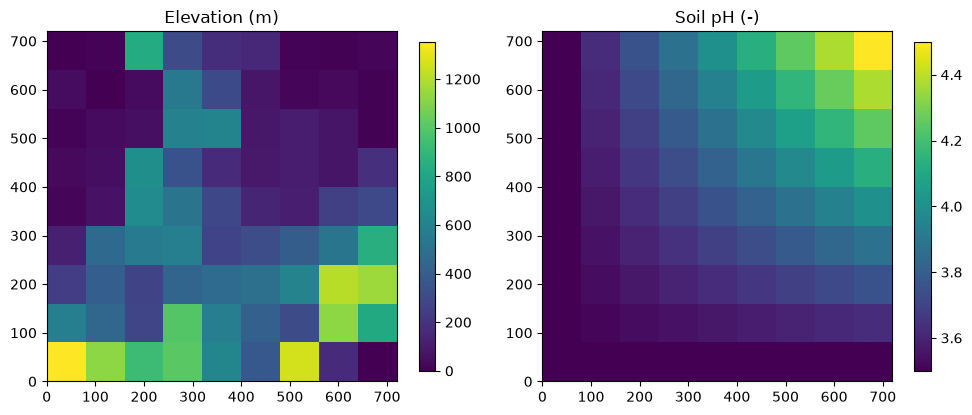

In [6]:
extent = [
    float(inputs["x"].min()),
    float(inputs["x"].max()),
    float(inputs["y"].min()),
    float(inputs["y"].max()),
]

# Make two side by side plots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))

# Elevation
im1 = ax1.imshow(inputs["elevation"].to_numpy(), extent=extent)
ax1.set_title("Elevation (m)")
fig.colorbar(im1, ax=ax1, shrink=0.7)

# Initial soil carbon
im2 = ax2.imshow(inputs["pH"].to_numpy(), extent=extent)
ax2.set_title("Soil pH (-)")
fig.colorbar(im2, ax=ax2, shrink=0.7)

plt.tight_layout()

For some variables, it may be useful to visualise spatial structure in 3 dimensions.
The obvious candidate is elevation.

In [7]:
# Map the y and x coordinates for each cell
y, x = xr.broadcast(inputs["y"], inputs["x"])
# Extract the elevation as the bar top and set the bottom as zero
top = inputs["elevation"].to_numpy()
bottom = np.zeros_like(top)
# Set the bar widths and depths
width = depth = 90

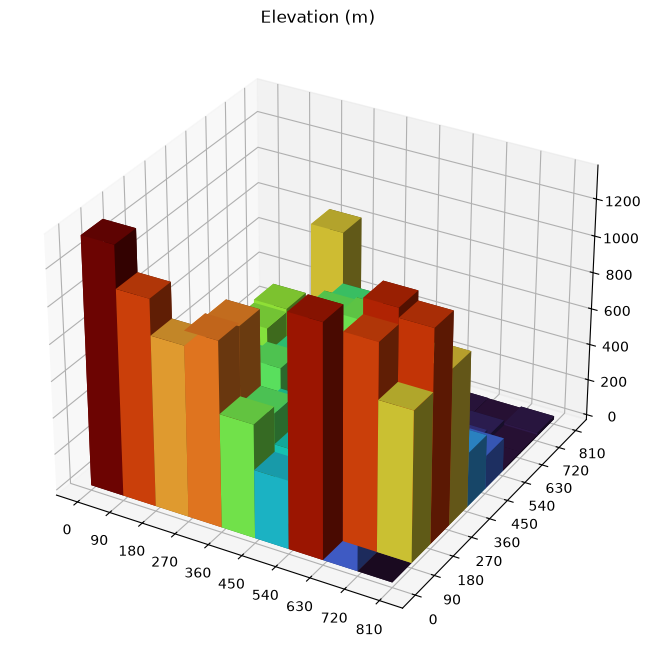

In [8]:
# Make a 3D barplot of the elevation
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")
colors = plt.cm.turbo(top.flatten() / float(top.max()))

# Plot the bars - the ravel() command flattens out the 2D arrays to give
# 1D arrays of bar locations and heights.
poly = ax.bar3d(
    x.to_numpy().ravel(),
    y.to_numpy().ravel(),
    bottom.ravel(),
    width,
    depth,
    top.ravel(),
    shade=True,
    color=colors,
)
ax.set_title("Elevation (m)")

cell_bounds = range(0, 811, 90)
ax.set_xticks(cell_bounds)
_ = ax.set_yticks(cell_bounds)

For other variables, such as air temperature and precipitation, the initial data
also provides time series data at reference height that are used to force the
simulation across the configured time period.

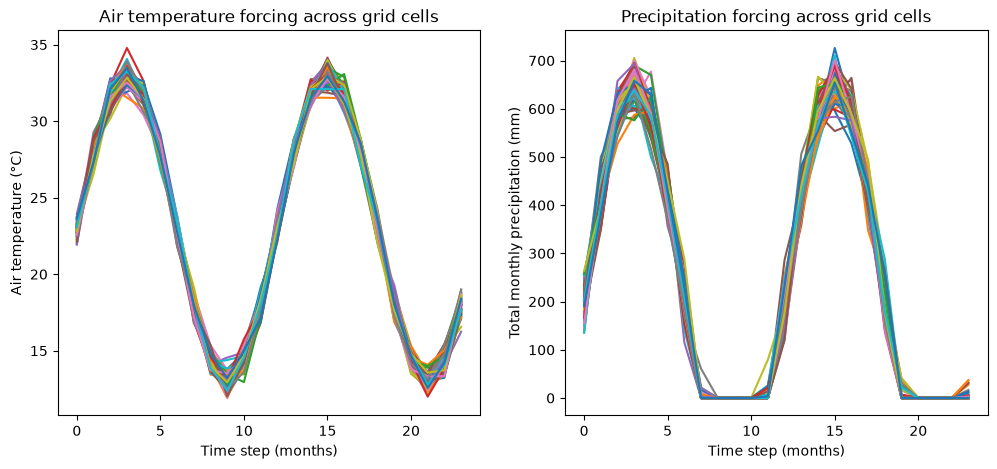

In [9]:
# Make two side by side plots
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Air temperature - stack is used here to map each cell onto the time_index
ax1.plot(
    inputs["time_index"], inputs["air_temperature_ref"].stack(dict(cell=["y", "x"]))
)
ax1.set_title("Air temperature forcing across grid cells")
ax1.set_ylabel("Air temperature (°C)")
ax1.set_xlabel("Time step (months)")

# Precipitation
ax2.plot(inputs["time_index"], inputs["precipitation"].stack(dict(cell=["y", "x"])))
ax2.set_title("Precipitation forcing across grid cells")
ax2.set_ylabel("Total monthly precipitation (mm)")
_ = ax2.set_xlabel("Time step (months)")

### Model initialisation

The `init` group contains the state of model variables that are calculated when the
science models initialise. The science models are initialised in a specific order
so that each model has access to required initialisation data either in
the inputs or by the initialisation of other models.

In [10]:
init = xr.load_dataset("ve_example/out/model_data.nc", group="init")
init

<xarray.Dataset> Size: 358kB
Dimensions:                               (layers: 14, y: 9, x: 9, pft: 2,
                                           element: 3, community_id: 81,
                                           functional_group_id: 20,
                                           time_index: 24, groundwater_layers: 2)
Coordinates:
  * layers                                (layers) int64 112B 0 1 2 ... 11 12 13
    layer_roles                           (layers) <U7 392B 'above' ... 'subs...
  * y                                     (y) int32 36B 720 630 540 ... 180 90 0
  * x                                     (x) int32 36B 0 90 180 ... 540 630 720
  * pft                                   (pft) <U9 72B 'broadleaf' 'shrub'
  * element                               (element) <U1 12B 'C' 'N' 'P'
  * community_id                          (community_id) int64 648B 0 1 ... 80
  * functional_group_id                   (functional_group_id) <U30 2kB 'car...
  * time_index                            (time_index) int64 192B 0 1 ... 22 23
  * groundwater_layers                    (groundwater_layers) int64 16B 14 15
Data variables: (12/69)
    atmospheric_co2                       (layers, y, x) float64 9kB 400.0 .....
    seed_turnover_cnp                     (pft, element, y, x) float64 4kB 0....
    condensation                          (layers, y, x) float64 9kB nan ... nan
    layer_leaf_mass                       (layers, y, x) float64 9kB nan ... nan
    foliage_turnover_cnp                  (pft, element, y, x) float64 4kB 0....
    subcanopy_vegetation_litter_lignin    (y, x) float64 648B 0.2 0.2 ... 0.2
    ...                                    ...
    root_turnover_cnp                     (pft, element, y, x) float64 4kB 0....
    matric_potential                      (layers, y, x) float64 9kB nan ... ...
    vapour_pressure                       (layers, y, x) float64 9kB 2.259 .....
    vapour_pressure_deficit_ref           (time_index, y, x) float64 16kB 0.4...
    atmospheric_pressure                  (layers, y, x) float64 9kB 100.6 .....
    arbuscular_mycorrhizal_n_supply       (y, x) float64 648B 0.002428 ... 0....

A good example is the layer heights within the simulation - this is calculated from the
configuration of ground layers and the heights of trees in the initial plant community data
and provides the vertical structure for the calculation of initial abiotic conditions and
other model components

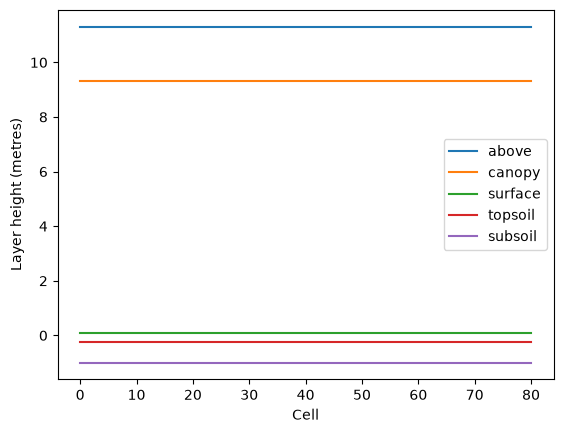

In [11]:
# Loop over vertical layers
for layer in init["layers"]:
    # Get the data for the layer
    layer_data = init["layer_heights"].sel(layers=layer)

    if not np.all(np.isnan(layer_data)):
        # Only plot layers that contain some canopy or other data.
        plt.plot(
            layer_data.stack(dict(cell=["y", "x"])),
            label=init["layer_roles"].sel(layers=layer).data,
        )
    plt.xlabel("Cell")
    plt.ylabel("Layer height (metres)")
    plt.legend()

### Model outputs

The main output of interest is the `outputs` group, which contains
variables describing the change in the models through the simulation process.

In [12]:
outputs = xr.load_dataset("ve_example/out/model_data.nc", group="outputs")
outputs

<xarray.Dataset> Size: 8MB
Dimensions:                                   (time_index: 24, layers: 14,
                                               y: 9, x: 9, element: 3, pft: 2,
                                               groundwater_layers: 2)
Coordinates:
  * time_index                                (time_index) int64 192B 0 1 ... 23
  * layers                                    (layers) int64 112B 0 1 ... 12 13
    layer_roles                               (layers) <U7 392B 'above' ... '...
  * y                                         (y) int32 36B 720 630 540 ... 90 0
  * x                                         (x) int32 36B 0 90 180 ... 630 720
  * element                                   (element) <U1 12B 'C' 'N' 'P'
  * pft                                       (pft) <U9 72B 'broadleaf' 'shrub'
  * groundwater_layers                        (groundwater_layers) int64 16B ...
Data variables: (12/118)
    transpiration                             (time_index, layers, y, x) float64 218kB ...
    soil_enzyme_maom_bacteria                 (time_index, y, x) float64 16kB ...
    subcanopy_seedbank_litter_cnp             (time_index, element, y, x) float64 47kB ...
    surface_runoff                            (time_index, y, x) float64 16kB ...
    baseflow                                  (time_index, y, x) float64 16kB ...
    layer_leaf_mass                           (time_index, layers, y, x) float64 218kB ...
    ...                                        ...
    soil_cnp_pool_necromass                   (time_index, element, y, x) float64 47kB ...
    arbuscular_mycorrhizal_n_supply           (time_index, y, x) float64 16kB ...
    river_discharge_rate                      (time_index, y, x) float64 16kB ...
    plant_phosphorus_uptake                   (time_index, y, x) float64 16kB ...
    subsurface_flow                           (time_index, y, x) float64 16kB ...
    plant_symbiote_carbon_supply              (time_index, y, x) float64 16kB ...

This group contains the values of variables as they are updated during the model
iteration. All the data in this group has a time dimension, so we can visualise it
across time. This can happen in a number of formats such as spatial grids, individual
time series within grid cells and as the three dimensional structure of the vertical
layers within the simulation. We describe these plotting processes below.

#### Spatial data

Using the soil carbon  held as **mineral-associated organic matter** as an example:

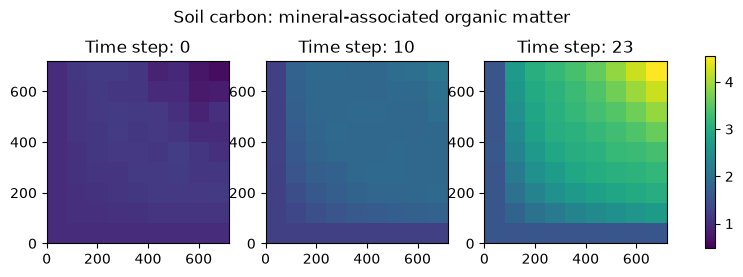

In [13]:
# Extract the carbon data
soil_maom_carbon = outputs["soil_cnp_pool_maom"].sel(element="C")

# Make three side by side plots
fig, axes = plt.subplots(ncols=3, figsize=(10, 5))

# Plot start and end MAOM
val_min = soil_maom_carbon.min()
val_max = soil_maom_carbon.max()

# Plot 3 time slices
for idx, ax in zip([0, 10, 23], axes):
    im = ax.imshow(
        soil_maom_carbon.sel(time_index=idx),
        extent=extent,
        vmax=val_max,
        vmin=val_min,
    )
    ax.set_title(f"Time step: {idx}")

fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.5)
_ = plt.suptitle("Soil carbon: mineral-associated organic matter", y=0.78, x=0.45)

#### Temporal data

The plot below shows the **mineral-associated organic matter** data as a time series
showing the values in each cell across time.

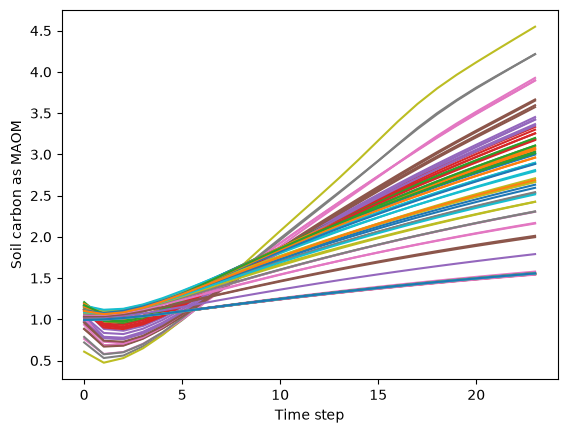

In [14]:
plt.plot(outputs["time_index"], soil_maom_carbon.stack(dict(cell=["y", "x"])))
plt.xlabel("Time step")
_ = plt.ylabel("Soil carbon as MAOM")

#### Vertical structure

The layer heights shown in the initial data example above provide the vertical
structure used throughout the simulation. The plot below shows the microclimatic
estimates of air temperature through the vertical structure of the canopy.

In [15]:
# Extract the layer heights and temperatures for all observations at a
# given time step.
t = 0
layer_heights = outputs["layer_heights"].sel(time_index=t)
temperature = outputs["air_temperature"].sel(time_index=t)

# Broadcast the x and y coordinates onto the observations.
layer_heights, temperature, yy, xx = xr.broadcast(
    layer_heights,
    temperature,
    outputs["y"],
    outputs["x"],
)

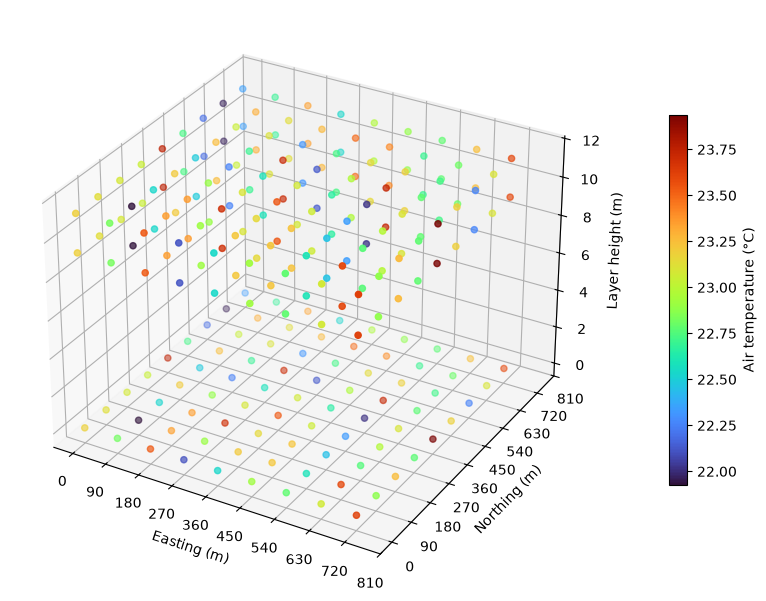

In [16]:
# Generate a 3 dimensional plot of layer heights showing temperature,
# unpacking the 2D data arrays from above into 1D arrays using ravel()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")
paths = ax.scatter(
    xs=xx.to_numpy().ravel(),
    ys=yy.to_numpy().ravel(),
    zs=layer_heights.to_numpy().ravel(),
    c=temperature.to_numpy().ravel(),
    cmap=plt.get_cmap("turbo"),
)
fig.colorbar(
    paths,
    ax=ax,
    orientation="vertical",
    shrink=0.6,
    label="Air temperature (°C)",
    pad=0.1,
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_zlabel("Layer height (m)")

ax.set_xticks(cell_bounds)
_ = ax.set_yticks(cell_bounds)

In [17]:
%%bash
# Remove the example directory
rm -r ve_example